# Ejercicio de programación Regresión Lineal Multiple

# Laboratorio N° 2: Modelos de Regresión Lineal y Polinómica
**Asignatura:** Inteligencia Artificial 1  
**Dataset Utilizado:** Online News Popularity Dataset (UCI Machine Learning Repository)

### Descripción del Dataset:
Este conjunto de datos recopila un total de 39,747 artículos publicados por el medio digital *Mashable* durante un periodo de dos años. El objetivo del laboratorio es entrenar modelos predictivos capaces de estimar la popularidad de una noticia basándose en características estructurales, de contenido y temporales.

* **Número de Instancias (m):** 39,797 ejemplos de entrenamiento.
* **Número de Características Predictivas (n):** 58 variables completamente numéricas independientes (después de limpiar campos de texto).
* **Etiqueta / Target (y):** `shares` (Cantidad de veces que el artículo fue compartido en plataformas digitales).

### Objetivos del Laboratorio:
1. Implementar un modelo de **Regresión Lineal Multivariable** mediante Descenso por el Gradiente con normalización de características.
2. Construir y entrenar un modelo de **Regresión Polinómica Multivariable** evaluando su curva de optimización de costo.
3. Resolver analíticamente los parámetros óptimos del sistema mediante la **Ecuación de la Normal**.
4. Realizar al menos 100 predicciones comparativas para contrastar y validar la efectividad real de cada enfoque matemático.

In [2]:
# Utilizado para la manipulación y gestión de rutas de archivos en el sistema local
import os

# Computación matemática y operaciones con vectores/matrices de alta eficiencia
import numpy as np

# Manipulación, limpieza y estructuración de conjuntos de datos tabulares
import pandas as pd

# Herramientas fundamentales para la generación de gráficos y curvas de costo
from matplotlib import pyplot

# Configuración para que los gráficos se rendericen de forma integrada dentro del entorno local de VS Code
%matplotlib inline

## Paso 1: Carga y Preprocesamiento de Datos de Forma Local

En este bloque de código leeremos el archivo de datos `OnlineNewsPopularity.csv` ubicado en el directorio raíz o en una carpeta local de datos. Realizaremos las siguientes fases críticas de preparación:
1. Carga del archivo usando la librería `pandas`.
2. Eliminación de espacios en blanco residuales presentes en los nombres de las columnas.
3. Descarte de columnas de tipo *string* o no predictivas (`url` y `timedelta`) para asegurar que el dataset sea estrictamente numérico.
4. Separación de la matriz de características independientes ($X$) y el vector de etiquetas dependientes ($y$).
5. Impresión de las dimensiones del conjunto para certificar el cumplimiento de las restricciones del enunciado del problema ($m \ge 20000$, $n \ge 20$).

In [3]:
# Definición de la ruta local del archivo CSV (puedes ajustar el nombre según tu archivo local)
path_dataset = 'OnlineNewsPopularity.csv'

# Si deseas que se descargue directamente de internet de forma automática en tu script local, descomenta la siguiente línea:
# path_dataset = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00332/OnlineNewsPopularity.zip'

# Leer el archivo delimitado por comas
df = pd.read_csv(path_dataset)

# Eliminar espacios ocultos en los nombres de las columnas limpiando las cadenas
df.columns = df.columns.str.strip()

# Separar las características numéricas eliminando las columnas de texto no predictivas y la etiqueta objetivo
X_raw = df.drop(columns=['url', 'timedelta', 'shares']).values
y = df['shares'].values

# Obtener las dimensiones m y n del dataset cargado
m = y.size
n = X_raw.shape[1]

print(f"Verificación de las dimensiones del dataset:")
print(f" -> Número de ejemplos de entrenamiento (m): {m}")
print(f" -> Número de características predictivas (n): {n}")
print("\nVisualización de los primeros 5 ejemplos de las primeras 4 columnas de X:")
print(X_raw[:5, :4])

Verificación de las dimensiones del dataset:
 -> Número de ejemplos de entrenamiento (m): 39644
 -> Número de características predictivas (n): 58

Visualización de los primeros 5 ejemplos de las primeras 4 columnas de X:
[[1.20000000e+01 2.19000000e+02 6.63594467e-01 9.99999992e-01]
 [9.00000000e+00 2.55000000e+02 6.04743081e-01 9.99999993e-01]
 [9.00000000e+00 2.11000000e+02 5.75129531e-01 9.99999992e-01]
 [9.00000000e+00 5.31000000e+02 5.03787878e-01 9.99999997e-01]
 [1.30000000e+01 1.07200000e+03 4.15645617e-01 9.99999999e-01]]


## Paso 2: Normalización de Características (Escalamiento de Datos)

Dado que las distintas características predictivas poseen magnitudes sumamente dispares (por ejemplo, conteos de palabras en los miles frente a tasas de palabras clave entre 0 y 1), el algoritmo del Descenso por el Gradiente podría oscilar innecesariamente retrasando de gran manera su convergencia matemática. 

Implementamos la función `featureNormalize` que calcula el valor de la media ($\mu$) y de la desviación estándar ($\sigma$) de cada columna. Posteriormente, transforma cada dato restándole su media y dividiéndolo por su desviación estándar. Esto sitúa las variables en una escala comparable aproximada de entre -2 y +2.

In [4]:
def featureNormalize(X):
    """
    Normaliza las características en X calculando la media y la desviación estándar por columna.
    Devuelve la matriz escalada junto con los vectores mu y sigma para su posterior reutilización.
    """
    X_norm = X.copy()
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    
    # Evitar divisiones por cero en caso de características constantes reemplazando sigmas de 0 por 1
    sigma[sigma == 0] = 1
    
    # Aplicar la fórmula de normalización z = (x - mu) / sigma
    X_norm = (X - mu) / sigma
    
    return X_norm, mu, sigma

## Paso 3: Aplicación de Normalización y Adición del Término de Intersección ($x_0 = 1$)

En esta sección ejecutaremos la función de normalización sobre nuestra matriz de datos crudos independientes. Tras estabilizar las escalas numéricas, acoplaremos una columna compuesta enteramente por unos ($1$) a la izquierda de nuestra matriz. Esta adición es obligatoria en álgebra lineal vectorizada para poder multiplicar las entradas por el parámetro del sesgo u ordenada al origen $\theta_0$.

In [6]:
# Llamar a la función de normalización enviando nuestra matriz cruda X_raw
X_norm, mu, sigma = featureNormalize(X_raw)

# Insertar el vector columna de unos (X0 = 1) en la primera posición de la matriz
X_linear = np.concatenate([np.ones((m, 1)), X_norm], axis=1)

print(f"Dimensión final de la matriz X para Regresión Lineal (con término x0): {X_linear.shape}")
print("Primeros 2 registros de la matriz X normalizada lista para el entrenamiento:")
print(X_linear[:2, :])

Dimensión final de la matriz X para Regresión Lineal (con término x0): (39644, 59)
Primeros 2 registros de la matriz X normalizada lista para el entrenamiento:
[[ 1.00000000e+00  7.57447233e-01 -6.95210448e-01  3.27718727e-02
   6.75074648e-04  3.86578580e-02 -6.07462593e-01 -3.35566105e-01
  -4.26525775e-01 -3.04268192e-01  1.56474152e-01 -1.16482069e+00
  -2.36445017e-01  2.14887984e+00 -4.32947848e-01 -2.49487028e-01
  -4.76911337e-01 -5.19566229e-01 -3.74923515e-01 -2.99110670e-01
  -5.03187845e-01 -2.34755267e-01 -3.50734772e+00 -1.91917761e+00
  -9.82156467e-01 -9.27594897e-01 -2.37901396e+00 -1.77458739e-01
  -2.39676274e-01 -2.43925944e-01  2.22523233e+00 -4.78663628e-01
  -4.80454058e-01 -4.73760968e-01 -4.09826850e-01 -2.56820594e-01
  -2.72322187e-01 -3.88118062e-01  1.20063309e+00  1.07882676e+00
  -6.24921186e-01 -6.18275745e-01 -6.70540635e-01  6.70593243e-01
  -2.75945948e-01  3.46403242e-01 -2.69078506e-01  4.57827291e-01
  -3.66076587e-01  2.37337037e-01  6.38648774e-0

## Paso 4: Definición del Criterio de Error (Función de Costo)

Para evaluar matemáticamente la calidad predictiva de nuestros parámetros $\theta$ en cualquier punto del entrenamiento, implementamos la función de costo vectorizada `computeCostMulti`. Esta calcula el error cuadrático medio del sistema empleando la ecuación:

$$J(\theta) = \frac{1}{2m} \sum_{i=1}^{m} \left( h_\theta(x^{(i)}) - y^{(i)} \right)^2 = \frac{1}{2m} (X\theta - y)^T (X\theta - y)$$

El empleo de operaciones matriciales nativas de `numpy` asegura que el cómputo se realice velozmente de forma paralela en el procesador local.

In [7]:
def computeCostMulti(X, y, theta):
    """
    Calcula el costo J de utilizar theta como parámetro para la regresión lineal
    con múltiples variables para ajustar los puntos de datos en X e y.
    """
    m = y.shape[0] # Número de muestras de entrenamiento
    J = 0
    
    # Calcular las predicciones del modelo (hipótesis)
    h = np.dot(X, theta)
    
    # Aplicar la ecuación matricial del error cuadrático medio
    J = (1 / (2 * m)) * np.sum(np.square(h - y))
    
    return J

## Paso 5: Implementación del Algoritmo del Descenso por el Gradiente Múltiple

Creamos la rutina iterativa encargada de ajustar los coeficientes $\theta$ para minimizar el error acumulado. En cada paso, el algoritmo actualiza simultáneamente todos los parámetros desplazándose en dirección contraria al gradiente de la función de costo por medio de la regla:

$$\theta = \theta - \frac{\alpha}{m} X^T (X\theta - y)$$

La función almacena el valor resultante del costo en cada iteración para que podamos monitorear visualmente y certificar la correcta convergencia del aprendizaje del modelo.

In [9]:
def gradientDescentMulti(X, y, theta, alpha, num_iters):
    """
    Realiza el descenso por el gradiente para aprender los parámetros theta
    actualizando sus valores por num_iters pasos con una tasa de aprendizaje alpha.
    """
    m = y.shape[0] # Número de ejemplos de entrenamiento
    theta = theta.copy() # Preservar el vector theta original intacto
    J_history = [] # Lista destinada a registrar el historial de costos
    
    for i in range(num_iters):
        # Actualización simultánea vectorizada de todos los parámetros theta
        theta = theta - (alpha / m) * (np.dot(X, theta) - y).dot(X)
        
        # Registrar el costo calculado de la iteración actual en el historial
        J_history.append(computeCostMulti(X, y, theta))
        
    return theta, J_history

## MODELO 1: Entrenamiento y Análisis Gráfico de la Regresión Lineal Múltiple

Ha llegado el momento de arrancar el proceso de entrenamiento de nuestro primer modelo. Inicializaremos el vector de coeficientes $\theta_{linear}$ en ceros de acuerdo a las características presentes en los datos. Definiremos una tasa de aprendizaje prudente ($\alpha = 0.01$) y realizaremos $1,500$ iteraciones para garantizar estabilidad. Concluido el proceso, graficaremos la evolución de $J(\theta)$ versus el número de iteraciones para comprobar visualmente la disminución del error.

Costo inicial del modelo lineal: 73167430.16598062
Costo final optimizado del modelo lineal: 66041012.09421555


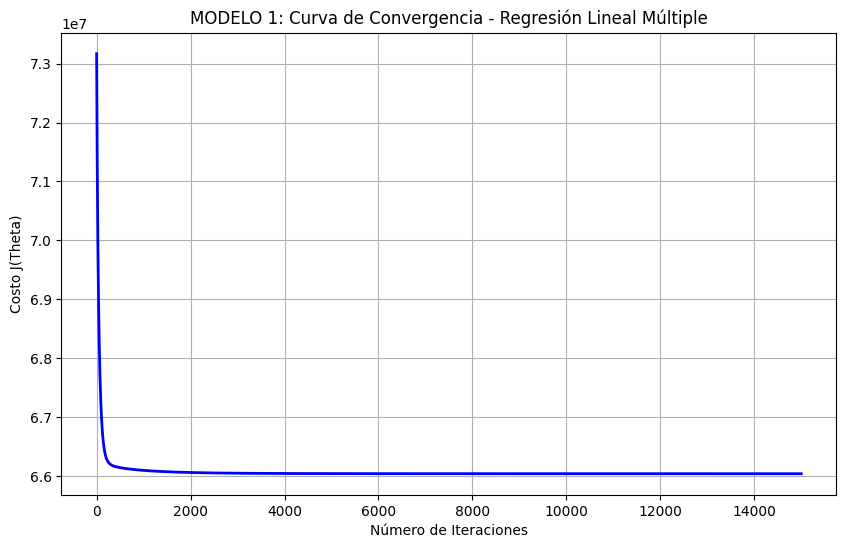

In [16]:
# Configuración de hiperparámetros del Descenso por el Gradiente
alpha_linear = 0.01
num_iters_linear = 15000

# Inicializar theta en ceros correlacionados con la forma de columnas de la matriz de características
theta_linear = np.zeros(X_linear.shape[1])

# Ejecutar el entrenamiento mediante el algoritmo implementado
theta_linear, J_history_linear = gradientDescentMulti(X_linear, y, theta_linear, alpha_linear, num_iters_linear)

# Desplegar en pantalla el costo final obtenido
print(f"Costo inicial del modelo lineal: {J_history_linear[0]}")
print(f"Costo final optimizado del modelo lineal: {J_history_linear[-1]}")

# Graficar la curva de convergencia del costo
pyplot.figure(figsize=(10, 6))
pyplot.plot(range(len(J_history_linear)), J_history_linear, color='blue', linewidth=2)
pyplot.xlabel('Número de Iteraciones')
pyplot.ylabel('Costo J(Theta)')
pyplot.title('MODELO 1: Curva de Convergencia - Regresión Lineal Múltiple')
pyplot.grid(True)
pyplot.show()

In [11]:
# Crear la matriz polinómica concatenando las características originales con su elevación al cuadrado
X_poly_raw = np.concatenate([X_raw, np.square(X_raw)], axis=1)

# Normalizar el nuevo espacio mapeado polinómico de datos independientes
X_poly_norm, mu_poly, sigma_poly = featureNormalize(X_poly_raw)

# Añadir el término constante de intersección (columna de unos para x0)
X_polynomial = np.concatenate([np.ones((m, 1)), X_poly_norm], axis=1)

print(f"Dimensión de la matriz original X: {X_raw.shape}")
print(f"Dimensión de la nueva matriz expandida para Regresión Polinómica: {X_polynomial.shape}")

Dimensión de la matriz original X: (39644, 58)
Dimensión de la nueva matriz expandida para Regresión Polinómica: (39644, 117)


## Entrenamiento y Análisis Gráfico del Modelo 2 (Regresión Polinómica)

Procederemos de manera análoga inicializando un nuevo vector de parámetros $\theta_{polynomial}$ en ceros con dimensiones ajustadas a la matriz expandida. Utilizaremos los mismos parámetros de entrenamiento ($\alpha = 0.01$, $1,500$ iteraciones) y visualizaremos su respectivo gráfico de costo para validar la convergencia estable del modelo enriquecido.

Costo inicial del modelo polinómico: 73123399.47505578
Costo final optimizado del modelo polinómico: 65632246.07431654


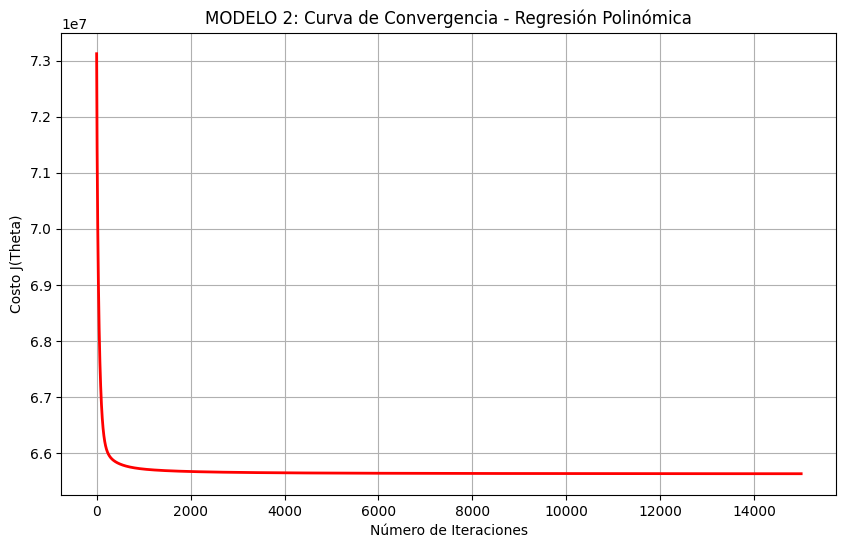

In [17]:
# Inicializar theta polinómico en ceros según la cantidad de columnas expandidas
theta_poly = np.zeros(X_polynomial.shape[1])

# Configuración de hiperparámetros estables
alpha_poly = 0.01
num_iters_poly = 15000

# Ejecutar el descenso por el gradiente sobre la estructura de datos polinómica
theta_poly, J_history_poly = gradientDescentMulti(X_polynomial, y, theta_poly, alpha_poly, num_iters_poly)

print(f"Costo inicial del modelo polinómico: {J_history_poly[0]}")
print(f"Costo final optimizado del modelo polinómico: {J_history_poly[-1]}")

# Graficar la curva de convergencia del costo para el Modelo 2
pyplot.figure(figsize=(10, 6))
pyplot.plot(range(len(J_history_poly)), J_history_poly, color='red', linewidth=2)
pyplot.xlabel('Número de Iteraciones')
pyplot.ylabel('Costo J(Theta)')
pyplot.title('MODELO 2: Curva de Convergencia - Regresión Polinómica')
pyplot.grid(True)
pyplot.show()

## MODELO 3: Cálculo por la Ecuación de la Normal (Solución Analítica Directa)

A diferencia del descenso por el gradiente, la Ecuación de la Normal calcula directamente los valores óptimos de $\theta$ de manera exacta sin requerir ciclos iterativos ni procesos de normalización previa de los datos. Implementamos la función `normalEqn` utilizando la inversa generalizada o pseudoinversa (`np.linalg.pinv`) para blindar el código matemático ante posibles matrices singulares o multicolineales:

$$\theta = (X^T X)^{-1} X^T y$$

In [13]:
def normalEqn(X, y):
    """
    Calcula la solución de forma cerrada para la regresión lineal utilizando
    la ecuación de la normal. Devuelve los parámetros theta óptimos calculados analíticamente.
    """
    theta = np.zeros(X.shape[1])
    
    # Aplicar la fórmula matricial exacta analítica usando la pseudoinversa de Moore-Penrose
    theta = np.dot(np.dot(np.linalg.pinv(np.dot(X.T, X)), X.T), y)
    
    return theta

In [ ]:
price = np.dot(X_array, theta)   # Se debe cambiar esto

print('El precio predecido para una casa de 1222 sq-ft y 3 dormitorios (usando el descenso por el gradiente): ${:.0f}'.format(price))

El precio predecido para una casa de 1222 sq-ft y 3 dormitorios (usando el descenso por el gradiente): $233499


## Cómputo Analítico de Parámetros Mediante la Ecuación de la Normal

Para la correcta ejecución de este modelo directo, utilizaremos los datos independientes **originales (sin normalizar)**, ya que la ecuación calcula la correlación exacta en las escalas reales de las variables independientes. Únicamente concatenaremos la columna obligatoria de unos ($x_0 = 1$) a la izquierda de la matriz original cruda para resolver analíticamente el vector $\theta_{normal}$.

In [14]:
# Añadir la columna de unos a la matriz original de características sin normalizar
X_normal_base = np.concatenate([np.ones((m, 1)), X_raw], axis=1)

# Resolver de forma analítica directa e instantánea el vector theta óptimo
theta_normal = normalEqn(X_normal_base, y)

print(f"Dimensiones de la matriz X procesada por Ecuación de la Normal: {X_normal_base.shape}")
print(f"Primeros 5 coeficientes theta calculados analíticamente por la Normal:")
print(theta_normal[:5])

Dimensiones de la matriz X procesada por Ecuación de la Normal: (39644, 59)
Primeros 5 coeficientes theta calculados analíticamente por la Normal:
[-6.11776847e+02  9.45661039e+01  4.22895452e-01  4.91686982e+02
 -8.31853083e+02]


## Validación de los Tres Modelos: Demostración de Efectividad con 100 Predicciones

Para evaluar, contrastar y comprobar de manera fehaciente la efectividad y precisión práctica de los tres algoritmos desarrollados locales, tomaremos una muestra de **100 ejemplos de prueba** extraídos directamente de las filas de nuestro dataset. 

Calcularemos las predicciones estimadas de popularidad utilizando cada uno de los modelos entrenados. Para los Modelos 1 y 2, los nuevos datos de entrada se normalizarán rigurosamente utilizando las medias ($\mu$) y desviaciones estándares ($\sigma$) previamente almacenadas de sus correspondientes conjuntos de entrenamiento. Desplegaremos los resultados en una tabla estructurada comparando el Valor Real versus cada predicción.

In [15]:
# Seleccionar un lote de 100 registros continuos para evaluar la validación
indices_prediccion = range(200, 300)

valores_reales = y[indices_prediccion]
datos_crudos_test = X_raw[indices_prediccion, :]

# Listas para almacenar las predicciones resultantes
predicciones_lineal = []
predicciones_poly = []
predicciones_normal = []

for i in range(100):
    registro_crudo = datos_crudos_test[i, :]
    
    # ---- 1. Predicción con Modelo de Regresión Lineal Múltiple ----
    registro_lineal_norm = (registro_crudo - mu) / sigma
    registro_lineal_ready = np.insert(registro_lineal_norm, 0, 1) # Insertar x0=1
    pred_lin = np.dot(registro_lineal_ready, theta_linear)
    predicciones_lineal.append(pred_lin)
    
    # ---- 2. Predicción con Modelo de Regresión Polinómica ----
    registro_poly_raw = np.concatenate([registro_crudo, np.square(registro_crudo)])
    registro_poly_norm = (registro_poly_raw - mu_poly) / sigma_poly
    registro_poly_ready = np.insert(registro_poly_norm, 0, 1) # Insertar x0=1
    pred_p = np.dot(registro_poly_ready, theta_poly)
    predicciones_poly.append(pred_p)
    
    # ---- 3. Predicción con Modelo de la Ecuación de la Normal ----
    registro_normal_ready = np.insert(registro_crudo, 0, 1) # Insertar x0=1 usando datos sin escalar
    pred_norm = np.dot(registro_normal_ready, theta_normal)
    predicciones_normal.append(pred_norm)

# Estructurar los resultados en un DataFrame de Pandas para visualizarlos de manera elegante y limpia
tabla_resultados = pd.DataFrame({
    'Muestra / ID': range(1, 101),
    'Valor Real (Shares)': valores_reales,
    'Pred. Lineal Multivariable': np.round(predicciones_lineal, 2),
    'Pred. Polinómica': np.round(predicciones_poly, 2),
    'Pred. Ec. de la Normal': np.round(predicciones_normal, 2)
})

# Mostrar las primeras 25 predicciones de las 100 calculadas como muestra clara en el output del cuaderno
print("Resumen de las primeras 25 predicciones de la demostración de validación:")
print(tabla_resultados.head(25).to_string(index=False))

# Guardar la totalidad de las 100 predicciones en un archivo local CSV para entregar o adjuntar si es requerido
tabla_resultados.to_csv('predicciones_laboratorio2.csv', index=False)
print("\n[Éxito]: Las 100 predicciones detalladas han sido calculadas y almacenadas localmente en 'predicciones_laboratorio2.csv'")

Resumen de las primeras 25 predicciones de la demostración de validación:
 Muestra / ID  Valor Real (Shares)  Pred. Lineal Multivariable  Pred. Polinómica  Pred. Ec. de la Normal
            1                 7500                     1266.14           1466.48                  661.93
            2                  441                     2061.90           2117.97                 2007.14
            3                  922                     1910.39           1946.04                 1501.29
            4                  473                     1575.50           1452.42                 1358.80
            5                 3200                     3327.11           4367.48                 3390.57
            6                 1600                      918.72           1032.65                  756.45
            7                 1300                     5021.47           5255.37                 5054.22
            8                 1300                     1206.07           1370.46      